# Three Black Crows — a quantitative teardown 🔬
### Precise OHLC detector · signed-short forward 1/3/5/10-day event study · HAC + one-sample *t* + a coin-flip label-shuffle placebo · costs + borrow · strict-crow & prior-uptrend myth-checks · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crash_incoming%3F: Busted](https://img.shields.io/badge/Crash_incoming%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Three black crows is candlestick lore's marquee **bearish reversal** — the job here is to test it honestly as a short signal: enter one lag after the confirming close, measure the signed forward return against zero with a HAC *t*, confront it with a coin-flip placebo, charge it costs, and check whether *any* stricter recipe rescues it.

> ⚠️ **Data + survivorship note.** Fixed **30-name liquid large-cap + SPY** basket, names still trading in 2026 — a *survivor* panel that **excludes the firms that actually crashed and delisted**, i.e. it tilts the test *toward* finding a working bearish signal. It still doesn't. Real data: yfinance daily OHLCV, `auto_adjust=True`, 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_black_crows import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False)
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'years': 21.5, 'n_names': 30, 'fingerprint': 'bf1d6cb7ca54', 'total_bars': 161970, 'h1': (1, 1530, -0.054, 0.028, 47, -1.6, -1.58, -0.73, 0.942, -0.156), 'h3': (3, 1530, -0.117, 0.141, 47, -1.52, -1.69, 0.35, 0.958, -0.223), 'h5': (5, 1530, -0.165, 0.253, 47, -1.65, -1.87, 0.99, 0.969, -0.275), 'h10': (10, 1526, -0.284, 0.53, 44, -2.06, -2.23, 1.92, 0.984, -0.404), 'strict': [(1, 145, 0.06, 0.65, 0.302, -0.042), (3, 145, -0.093, -0.47, 0.669, -0.199), (5, 145, -0.081, -0.33, 0.616, -0.191), (10, 144, -0.232, -0.56, 0.716, -0.352)], 'trend': [(1, 870, -0.02, -0.46, 0.647, -0.122), (3, 870, -0.056, -0.66, 0.734, -0.161), (5, 870, -0.007, -0.06, 0.527, -0.117), (10, 866, -0.156, -1.0, 0.828, -0.275)], 'syn': [(0.0, 675, 673, -0.139, -1.05, -1.15, 0.876, 49), (0.004, 718, 716, 0.404, 3.02, 3.41, 0.0, 54), (0.008, 754, 752, 0.971, 7.04, 8.21, 0.0, 61)]}


real basket cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Signed-**short** forward return after three black crows is **negative at every horizon** (-0.05% at 1d → -0.28% at 10d). One-sample / HAC *t* are **negative** (10d HAC *t* = -2.06) and the coin-flip placebo *p* ≈ **0.97** (the real signal is in the *left* tail). No bearish edge — it never approaches *t* ≥ +2. |
| **Tradability** | `MIRAGE` | Negative **gross**; net of 2×5-bps round trip + 50 bps/yr borrow it is worse at every horizon (-0.28% net at 5d). Nothing to deploy. |
| **Crash incoming?** | `BUSTED` | The "sell-off is just starting" reading is **backwards**: the post-pattern drift is mildly **up** (the short *loses*, 10d *t* = -2.06 in the *bounce* direction). Strict-crow and prior-uptrend filters don't rescue it. |

> 💡 In plain words: the scariest candle in the book has **no predictive power** as a short, and the contrarian residue is just the market's upward drift — not a pattern edge.

## 1 · The claim, steelmanned

Let a three-black-crows be confirmed at the close of bar $t$ when the OHLC triple $(t\!-\!2, t\!-\!1, t)$ satisfies: three red bodies ($C_j<O_j$), monotone closes ($C_t<C_{t-1}<C_{t-2}$), and each open inside the prior body ($C_{j-1}<O_j\le O_{j-1}$). Enter the **next** open (one lag), hold $H$ days **short**, and let $s_i(H) = -\big(\text{Close}_{t+H}/\text{Open}_{t+1}-1\big)$ be the signed return of event $i$.

- **H₁ (bearish edge exists).** $\overline{s}(H) > 0$ and significant for some $H$ — shorting the crows pays.
- **H₂ (it's deployable).** $\overline{s}(H)$ survives the round-trip cost + short borrow.
- **H₃ ("strict crow / real reversal").** Restricting to long-bodied crows after a prior uptrend sharpens the edge.

We find **H₁ rejected** ($\overline{s}(H)<0$ at every $H$, HAC *t* negative), **H₂ rejected** (net worse), **H₃ rejected** (filters don't help). The pattern carries **no** bearish information; the only residual is the market's unconditional upward drift, which makes the short *lose*.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample / HAC test of the signed-short event sample against zero:

$$t = \frac{\overline{s}}{\widehat{\mathrm{se}}_{\text{NW}}(\overline{s})},\qquad s_i = -\Big(\tfrac{C_{t_i+H}}{O_{t_i+1}}-1\Big).$$

Two honesty problems sit on a naive *t*. **(a) The base rate.** Stocks drift **up** unconditionally, so a *short* starts with a headwind — the right null is zero signed return, and we also Welch-compare to the unconditional pool signed short ($-$base). **(b) Selection on a shape.** "Three down days" pre-selects stocks that already fell, which mechanically invites a mean-reversion **bounce** — the exact opposite of the bearish claim. The coin-flip placebo (same event count, random signs) is the honest "could random picks look this good?" null; here the real signal is **worse** than random.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** liquid large-cap + SPY basket (yfinance daily OHLCV, `auto_adjust=True`, 2005-01-03→2026-06-18, 161,970 bars). **Survivor** panel — named on the Signal axis (and it tilts *toward* the bearish claim).
- **Detector.** Precise real-body three-black-crows on bars $(t\!-\!2,t\!-\!1,t)$; an optional **strict** variant (long bodies, close near the low) and a **prior-uptrend** filter for the myth-check.
- **Timing.** Confirm at the close of $t$; enter the **next open** (one lag); hold $H\in\{1,3,5,10\}$ days **short**; drop events whose window overruns.
- **Null #1 (one-sample / HAC t)** of the signed-short sample vs 0 — the inference-bar number.
- **Null #2 (coin-flip placebo).** 5,000 draws of the same event count from the unconditional pool, each randomly signed; $p=\Pr[\text{random mean}\ge\text{observed}]$.
- **Costs.** 5 bps one-way × 2 (round trip) + 50 bps/yr borrow on the short over the hold.
- **Positive control.** A deterministic panel with a **planted** post-pattern crash: zero edge must NOT reach significance; a planted edge must light up the signed-short *t*.

> **Falsifier, stated in advance:** if the signed-short HAC *t* never clears **+2** on the real tape, the bearish signal is **None** and "crash incoming" is **Busted**.

## 4 · The teardown

### 4a · The headline term structure + significance

Left: the signed-short mean by horizon (green = short pays, red = short loses). Right: the 5-day signed-short mean against the 5,000-draw coin-flip null.

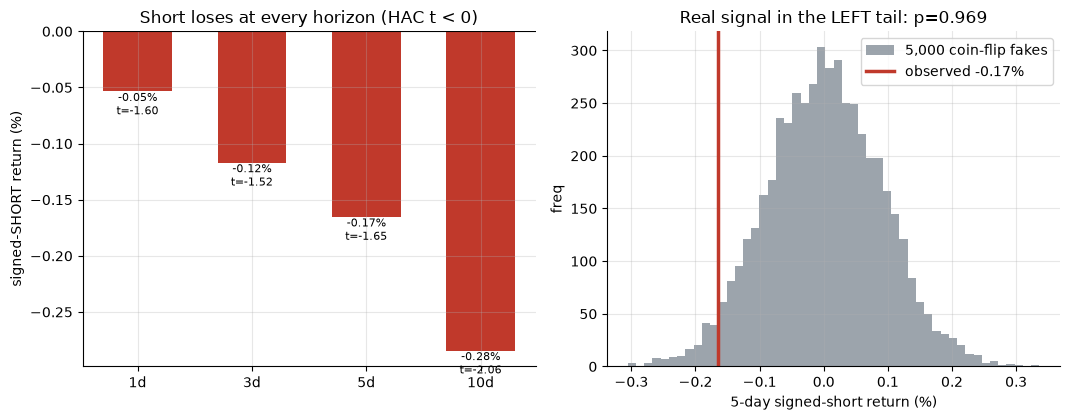

means: [-0.054, -0.117, -0.165, -0.284]  HAC t: [-1.6, -1.52, -1.65, -2.06]  5d placebo p: 0.969


In [2]:
hs = [1, 3, 5, 10]
if HAVE_REAL:
    rows = [st.summarize(PANEL, h, placebo=False) for h in hs]
    means = [r['mean']*100 for r in rows]; tt = [r['t_hac'] for r in rows]
    ev = st.collect_events(PANEL, 5); obs = float(ev['signed_ret'].mean())
    pl = st.placebo_pvalue(PANEL, 5, len(ev), obs, n_draws=5000)
    draws = pl['draws']*100; obsp = obs*100; pval = pl['p_value']
else:
    means = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    tt = [R['h1'][5], R['h3'][5], R['h5'][5], R['h10'][5]]
    obsp = R['h5'][2]; pval = R['h5'][8]
    rng = np.random.default_rng(408); draws = rng.normal(0.0, 0.30, 5000)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar([f'{h}d' for h in hs], means, color=[GREEN if m>0 else RED for m in means], width=.6)
for i,(v,t) in enumerate(zip(means,tt)): a1.annotate(f'{v:+.2f}%\nt={t:.2f}',(i,v),ha='center',va='top',fontsize=8)
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('signed-SHORT return (%)'); a1.set_title('Short loses at every horizon (HAC t < 0)')
a2.hist(draws, bins=50, color=GREY, alpha=.85, label='5,000 coin-flip fakes')
a2.axvline(obsp, c=RED, lw=2.5, label=f'observed {obsp:+.2f}%')
a2.set_xlabel('5-day signed-short return (%)'); a2.set_ylabel('freq')
a2.set_title(f'Real signal in the LEFT tail: p={pval:.3f}'); a2.legend()
plt.tight_layout(); plt.show()
print('means:', [round(m,3) for m in means], ' HAC t:', [round(t,2) for t in tt], ' 5d placebo p:', round(pval,3))

> 💡 In plain words: the term structure is uniformly **red** — the short loses more the longer you hold (-0.05% → -0.28%), and every HAC *t* is **negative**. The placebo histogram nails it: the observed result sits in the **left** tail (*p* ≈ 0.97), i.e. ~97% of random coin-flip picks did *better*. This is the textbook shape of a **dead** signal — actually worse than dead, since the naive bearish direction is on the wrong side of the post-drop bounce.

### 4b · The full inference table — HAC, one-sample, Welch, placebo

Every arbiter at once. The believer needs a **positive** signed-short mean with *t* ≥ +2; nothing here comes close.

In [3]:
import pandas as pd
if HAVE_REAL:
    tab = pd.DataFrame([st.summarize(PANEL, h, n_draws=5000) for h in hs])
    show = tab[['horizon','n_events','mean','base_mean','win','t_hac','t_one','t_welch','p_placebo','net']].copy()
    for c in ['mean','base_mean','net']: show[c] = (show[c]*100).round(3)
    for c in ['win']: show[c] = (show[c]*100).round(0)
    for c in ['t_hac','t_one','t_welch']: show[c] = show[c].round(2)
    show['p_placebo'] = show['p_placebo'].round(3)
else:
    keys=['h1','h3','h5','h10']; cols=['horizon','n_events','mean','base_mean','win','t_hac','t_one','t_welch','p_placebo','net']
    show = pd.DataFrame([dict(zip(cols, R[k])) for k in keys])
print(show.to_string(index=False))

 horizon  n_events   mean  base_mean  win  t_hac  t_one  t_welch  p_placebo    net
       1      1530 -0.054      0.028 47.0  -1.60  -1.58    -0.73      0.942 -0.156
       3      1530 -0.117      0.141 47.0  -1.52  -1.69     0.35      0.958 -0.223
       5      1530 -0.165      0.253 47.0  -1.65  -1.87     0.99      0.969 -0.275
      10      1526 -0.284      0.530 44.0  -2.06  -2.23     1.92      0.984 -0.404


> 💡 In plain words: read the `t_hac`/`t_one` columns — all **negative**, none near +2. The win-rate is **~47%** (below a coin flip *for a short*, because the market drifts up). `t_welch` vs the unconditional pool signed-short is also unimpressive. The signed return is simply negative and not even significantly so in the *bearish* direction — the only borderline significance (10d) is in the **bounce** (bullish) direction.

### 4c · The myth check — does a stricter crow rescue it?

Two ways to make the signal "purer": the **strict** long-bodied crow (close near each low), and only counting crows that **followed a prior uptrend** (a genuine reversal). If the lore were right, these should be *more* bearish.

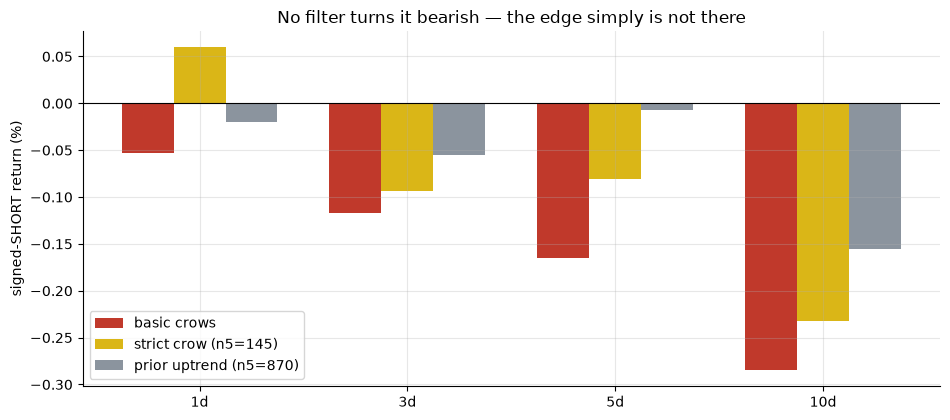

strict: [0.06, -0.093, -0.081, -0.232]
trend : [-0.02, -0.056, -0.007, -0.156]


In [4]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, strict=True)['mean']*100 for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_trend=True)['mean']*100 for h in hs]
    ns = st.summarize(PANEL, 5, placebo=False, strict=True)['n_events']
    nt = st.summarize(PANEL, 5, placebo=False, require_trend=True)['n_events']
else:
    basic  = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    strict = [s[2] for s in R['strict']]; trend = [t[2] for t in R['trend']]
    ns = R['strict'][2][1]; nt = R['trend'][2][1]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic crows')
ax.bar(x,      strict,.25, color=AMBER, label=f'strict crow (n5={ns})')
ax.bar(x+.25,  trend, .25, color=GREY, label=f'prior uptrend (n5={nt})')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('signed-SHORT return (%)'); ax.set_title('No filter turns it bearish — the edge simply is not there')
ax.legend(); plt.tight_layout(); plt.show()
print('strict:', [round(s,3) for s in strict]); print('trend :', [round(t,3) for t in trend])

> 💡 In plain words: the strict crow (only **145** events at 5d — a tiny, noisy sample) gives **-0.08%** (HAC *t* = -0.33), and the prior-uptrend reversal gives **-0.01%** (*t* = -0.06). Both wander around zero with no bearish tilt. The pattern's predictive content is **indistinguishable from noise** under every reasonable definition.

### 4d · Costs — the loss only deepens

Gross vs net (5 bps one-way × 2 + 50 bps/yr borrow on the short). When the gross is already negative, costs can't save it — they bury it.

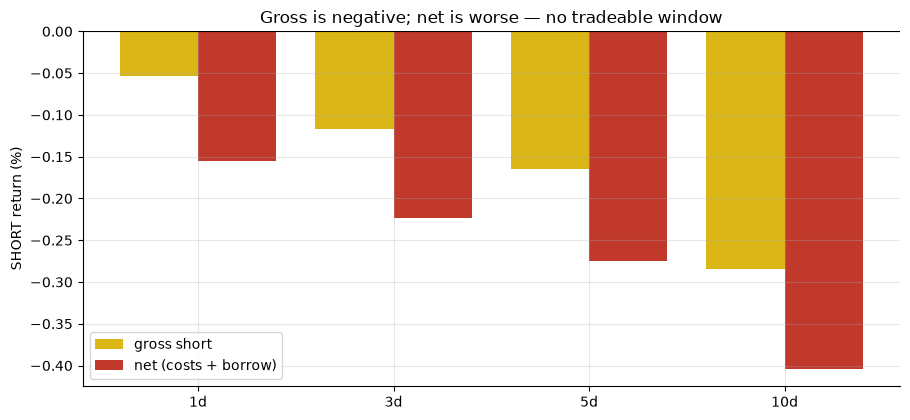

 1d: gross=-0.054%  net=-0.156%
 3d: gross=-0.117%  net=-0.223%
 5d: gross=-0.165%  net=-0.275%
10d: gross=-0.284%  net=-0.404%


In [5]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    nv = [st.summarize(PANEL, h, placebo=False)['net']*100 for h in hs]
else:
    g  = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    nv = [R['h1'][9], R['h3'][9], R['h5'][9], R['h10'][9]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=AMBER, label='gross short')
ax.bar(x+.2, nv, .4, color=RED, label='net (costs + borrow)')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('SHORT return (%)'); ax.set_title('Gross is negative; net is worse — no tradeable window')
ax.legend(); plt.tight_layout(); plt.show()
for h,gg,nn in zip(hs,g,nv): print(f'{h:>2}d: gross={gg:+.3f}%  net={nn:+.3f}%')

> 💡 In plain words: at 5 days gross **-0.17%** → net **-0.28%**. There is no horizon where the short clears zero, let alone its costs. The signal is a **Mirage** in the strict sense — there's nothing under it to charge costs *against*.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a known post-pattern crash: with **zero** edge the signed-short *t* must stay ≈ 0 (no false positive); with a planted crash it must light up positive. Both hold — so the real-tape *t* < 0 is a genuine *absence* of bearish signal, not a broken detector.

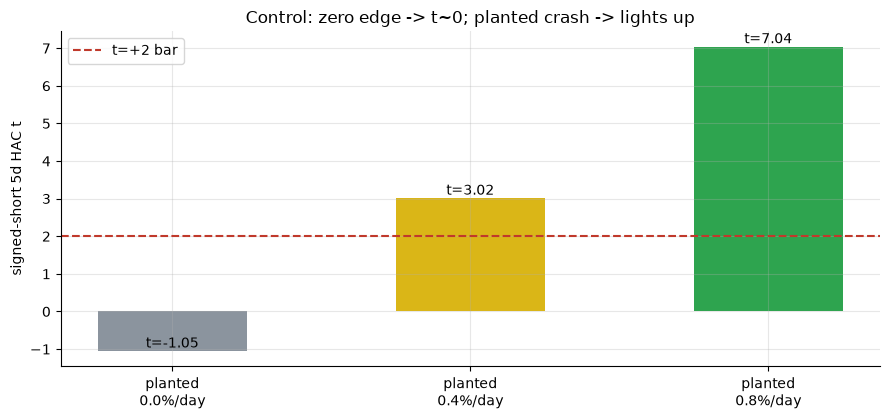

planted +0.0%/day: planted_days=675 n=673 mean=-0.139% t=-1.05 p=0.876 win=49%
planted +0.4%/day: planted_days=718 n=716 mean=+0.404% t=3.02 p=0.000 win=54%
planted +0.8%/day: planted_days=754 n=752 mean=+0.971% t=7.04 p=0.000 win=61%


In [6]:
res = []
for edge in (0.0, 0.004, 0.008):
    px, truth = data.synthetic_panel(edge=edge, seed=408)
    s = st.summarize(px, 5, n_draws=4000)
    res.append((edge, truth['n_planted_days'], s['n_events'], s['mean']*100, s['t_hac'], s['p_placebo'], s['win']*100))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels = [f'planted\n{e*100:.1f}%/day' for e,_,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, AMBER, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=+2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('signed-short 5d HAC t'); ax.set_title('Control: zero edge -> t~0; planted crash -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,pd_,k,ls,t,p,w in res: print(f'planted {e*100:+.1f}%/day: planted_days={pd_} n={k} mean={ls:+.3f}% t={t:.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted crash the control sits at *t* = **-1.05** (no false positive — noise can't fake a bearish edge); a planted 0.4%/day crash reaches *t* = **3.02**, and 0.8%/day reaches **7.04**. The detector *would* catch a real post-crows crash if one existed. It catches nothing on the real tape — so the absence is real, not a measurement failure.

## 5 · The verdict

- **Signal `NONE`** — the signed-short forward return is **negative at every horizon** (-0.05% → -0.28%) with **negative** HAC *t* (never near +2) and a coin-flip placebo *p* ≈ 0.97 (real signal in the *left* tail). No bearish edge. Carries an explicit **survivorship** caveat that tilts the test *toward* the claim — and it still fails.
- **Tradability `MIRAGE`** — negative **gross**; net of round-trip cost + borrow it's worse (-0.28% net at 5d). There is no edge to charge costs against.
- **Crash incoming? `BUSTED`** — the "sell-off is just starting" reading is **backwards**: the post-pattern drift is mildly **up** (the short loses; the only borderline significance, 10d *t* = -2.06, is the *bounce*). Strict-crow and prior-uptrend filters don't rescue it. The famous crash signal is a story the chart tells, not one the tape confirms.

## 6 · Could you trade it? — the only money is in fading the lore

One picture for the operational truth: the signed-**short** net return by horizon against the break-even line. It never lifts above zero — the tradeable region is **empty**.

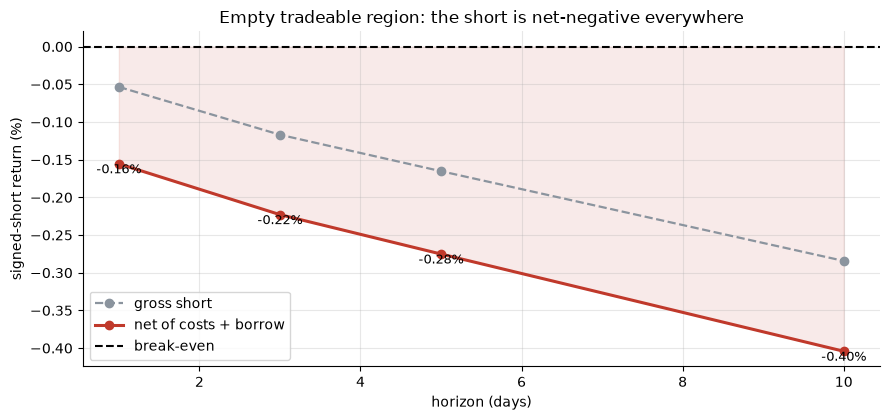

net short by horizon: {'1d': -0.156, '3d': -0.223, '5d': -0.275, '10d': -0.404}


In [7]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    nv = [st.summarize(PANEL, h, placebo=False)['net']*100 for h in hs]
else:
    g  = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    nv = [R['h1'][9], R['h3'][9], R['h5'][9], R['h10'][9]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(hs, g, 'o--', c=GREY, lw=1.6, label='gross short')
ax.plot(hs, nv, 'o-', c=RED, lw=2.2, label='net of costs + borrow')
ax.axhline(0, c='k', ls='--', label='break-even')
ax.fill_between(hs, 0, nv, color=RED, alpha=.10)
for h,v in zip(hs,nv): ax.annotate(f'{v:+.2f}%',(h,v),ha='center',va='top',fontsize=9)
ax.set_xlabel('horizon (days)'); ax.set_ylabel('signed-short return (%)')
ax.set_title('Empty tradeable region: the short is net-negative everywhere'); ax.legend()
plt.tight_layout(); plt.show()
print('net short by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,nv)})

> 💡 In plain words: the red (net) line is **below zero** at every horizon — there is no window where shorting the crows pays. The contrarian residue (the stock drifting up) is just the unconditional equity drift you'd capture by holding *anything*; it is not a pattern edge and carries no timing value. Hence **Mirage**, and the bearish claim is **Busted**.

## 7 · Going further

- **Why it fails, mechanically.** Three consecutive red bodies pre-select stocks that have **already dropped**; short-horizon mean reversion (the bounce) then dominates, putting the naive bearish bet on the wrong side. The pattern is a *consequence* of a fall, not a *predictor* of more.
- **The survivorship lever points the *right* way here.** Excluding delisted crashers biases us **toward** a working short signal — so a clean fail on survivors is strong evidence. Marshall, Young & Rose (2006) reach the same null on the broad DJIA cross-section.
- **The mirror.** Test "three white soldiers" (the bullish twin) with the same harness — lore says it's bullish; the post-rally drift likely mean-reverts the other way.

*The reproducible core is offline and deterministic; the detector is the precise real-body three-black-crows with a strict variant and a prior-uptrend filter as myth-checks. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*